In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt

def train_tensor_reconstruction(p: int,
                                H: int,
                                sigma2: float,
                                T: float,
                                num_epochs: int,
                                batch_size: int,
                                t_max = None,
                                no_target: bool = True,
                                device: str = "cuda"):
    """
    Train tensor factors u, v, w with gradient accumulation over mini-batches,
    without ever materializing the full (i,j,l) index tensor.
    Returns:
        u, v, w, epoch_loss_hist
    """
    if t_max is None:
        t_max = num_epochs
    t_arr = np.linspace(0,t_max,num_epochs)
    tau = t_arr[1]-t_arr[0]
    
    dev = torch.device(device if torch.cuda.is_available() else "cpu")
    sigma = sigma2 ** 0.5

    # — parameters only on GPU —
    u = nn.Parameter(torch.randn(H, p, device=dev) * sigma)
    v = nn.Parameter(torch.randn(H, p, device=dev) * sigma)
    w = nn.Parameter(torch.randn(H, p, device=dev) * sigma)

    optimizer = torch.optim.SGD([u, v, w], lr=tau / T)
    epoch_loss_hist = []

    total_idxs = p ** 3

    for epoch in tqdm(range(1, num_epochs + 1)):
        epoch_loss = 0.0

        # zero accumulated grad over epoch
        optimizer.zero_grad()

        # sequentially walk through flat indices in batches
        for start in range(0, total_idxs, batch_size):
            end = min(start + batch_size, total_idxs)
            flat_idx = torch.arange(start, end, device=dev)

            # recover (i,j,l)
            # i = idx // (p*p)
            # rem = idx % (p*p)
            # j = rem // p
            # l = rem % p
            i_batch = flat_idx.div(p * p, rounding_mode='floor')
            rem = flat_idx - i_batch * (p * p)
            j_batch = rem.div(p, rounding_mode='floor')
            l_batch = rem - j_batch * p

            # forward: elementwise product across H, then sum
            pred = (u[:, i_batch] * v[:, j_batch] * w[:, l_batch]).sum(dim=0)

            if no_target:
                tgt = torch.zeros_like(pred)
            else:
                # only those with i==j==l have target=1
                diag_mask = (i_batch == j_batch) & (j_batch == l_batch)
                tgt = diag_mask.to(pred.dtype)

            loss = 0.5 * (pred - tgt).pow(2).sum()
            loss.backward()
            epoch_loss += loss.item()

        # apply accumulated gradient once per epoch
        optimizer.step()

        epoch_loss_hist.append(epoch_loss)

    return u.detach(), v.detach(), w.detach(), np.array(epoch_loss_hist), t_arr

# Overparameterized

In [ ]:
loss_hists = []
# example usage
c_list = [1.0,0.5,0.25]
p = 32
H = p**3
L_0 = 1.0
t_max = 10.0
num_iters = 100
batch_size = int(2**14)
for c in c_list:
    sigma2 = (2*L_0/H)**(1/3)/p
    T = 6*H*sigma2**2/c
    u, v, w, loss_hist,t_arr = train_tensor_reconstruction(p, H, sigma2, T, num_iters,batch_size,t_max=t_max)
    loss_hists.append(loss_hist)

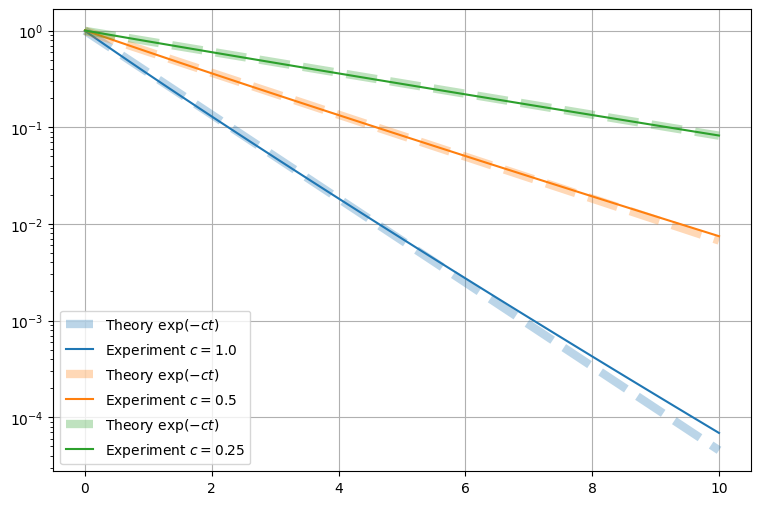

In [ ]:
plt.figure(figsize = (9,6))

for i in range(len(c_list)):
    c = c_list[i]
    line, = plt.plot(t_arr,np.exp(-c*t_arr), label=r'Theory $\exp(-ct)$',linestyle='--',linewidth=6,alpha=0.3)
    
    plt.plot(t_arr,loss_hists[i],color=line.get_color(),label=fr'Experiment $c={c}$')

plt.yscale('log')
#plt.xscale('log')
plt.grid()
plt.legend(loc='lower left')
plt.show()

# Underparameterized

In [ ]:
loss_hists_under = []
# example usage
c_list = [1.0,0.5,0.25]
p = 128
H = p
L_0 = 1.0
t_max = 100.0
num_iters = 1000
batch_size = int(2**20)
for c in c_list:
    sigma2 = (2*L_0/H)**(1/3)/p
    T = 4*p**2*sigma2**2/c
    
    u, v, w, loss_hist_under,t_arr_under = train_tensor_reconstruction(p, H, sigma2, T, num_iters,batch_size,t_max=t_max)
    loss_hists_under.append(loss_hist_under)

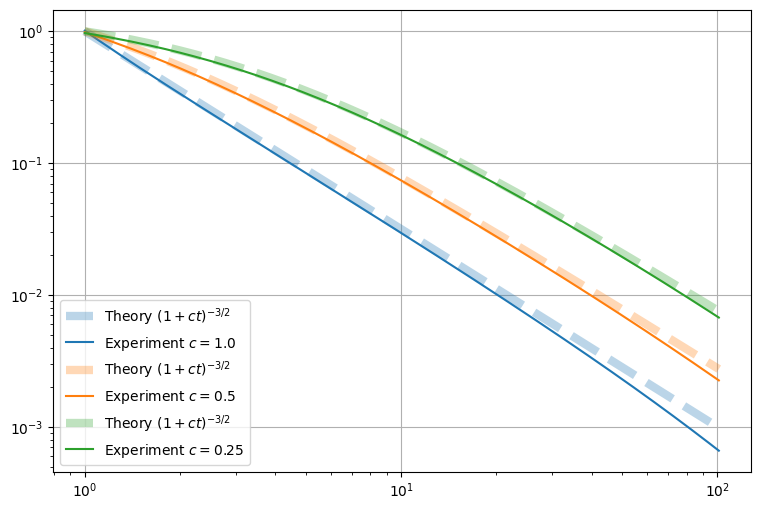

In [ ]:
plt.figure(figsize = (9,6))

for i in range(len(c_list)):
    c = c_list[i]
    line, = plt.plot(t_arr_under+1,(1+c*t_arr_under)**(-3.0/2), label=r'Theory $(1+ct)^{-3/2}$',linestyle='--',linewidth=6,alpha=0.3)

    plt.plot(t_arr_under+1,loss_hists_under[i],color=line.get_color(),label=fr'Experiment $c={c}$')

plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.legend(loc='lower left')
plt.show()